## Customer Churn Prediction 
Step1. imports

In [2]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics & utilities
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings("ignore")

# Display settings
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
pd.set_option('display.max_columns', 200)

## Step 2. Load the data

In [3]:

# Load dataset
df = pd.read_csv("D:\Projects\churn_rate\data\Churn_Modelling.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



## Step 3. Initial inspection

In [4]:
# Info & Summary
display(df.info())
display(df.describe(include='all'). T)

# Missing values
print("\nMissing values per column:")
print(df.isnull().sum)

# Target distribution
print("\nChurn value counts:")
print(df['Exited'].value_counts(normalize=False))
print("\nChurn proportion:")
print(df['Exited'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0



Missing values per column:
<bound method DataFrame.sum of       RowNumber  CustomerId  Surname  CreditScore  Geography  Gender    Age  \
0         False       False    False        False      False   False  False   
1         False       False    False        False      False   False  False   
2         False       False    False        False      False   False  False   
3         False       False    False        False      False   False  False   
4         False       False    False        False      False   False  False   
...         ...         ...      ...          ...        ...     ...    ...   
9995      False       False    False        False      False   False  False   
9996      False       False    False        False      False   False  False   
9997      False       False    False        False      False   False  False   
9998      False       False    False        False      False   False  False   
9999      False       False    False        False      False   False  Fa

## Step 4. Exploratory Data Analysis (visualizations) ##

We'll look at distributions of numeric features, relationships with churn and categorical features

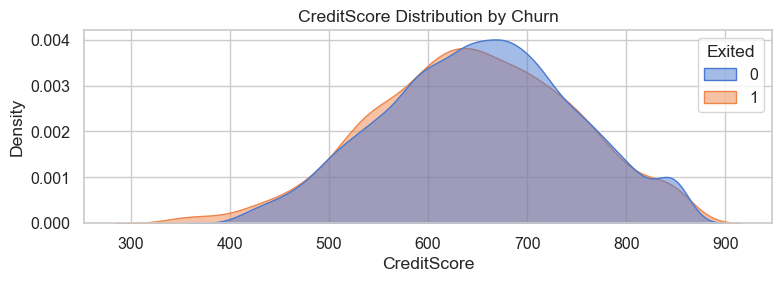

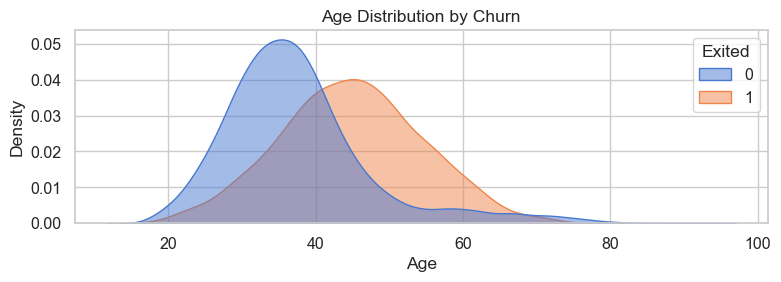

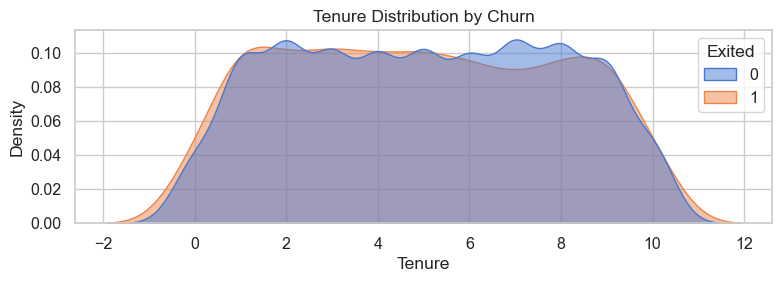

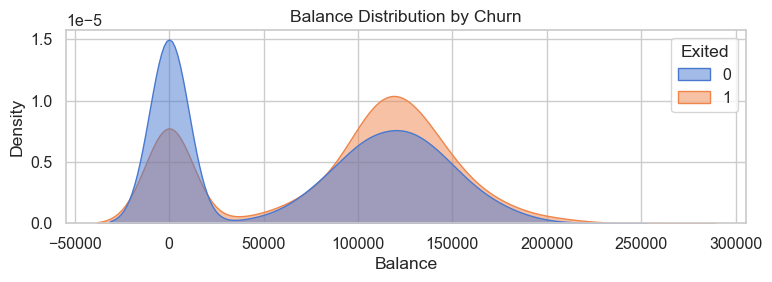

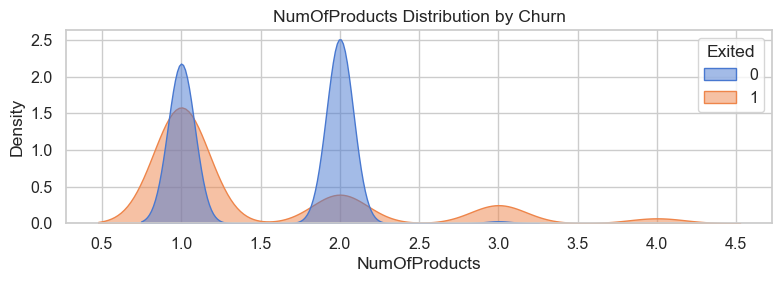

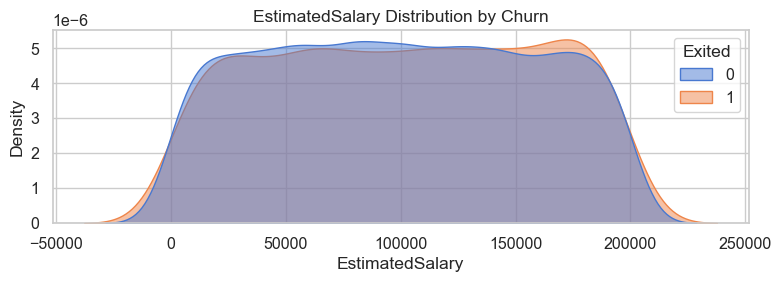

In [ ]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# --- Distribution plots
for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.kdeplot(data=df, x=col, hue='Exited', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'{col} Distribution by Churn')
    plt.tight_layout()
    plt.show()

## Understanding the graphs

### 1. Credit Score Distribution by Churn

What you see:

* Heavy overlap between churned (1) and non-churned (0)
* Slight shift: churned customers tend to have slightly lower credit scores

Insight:
* Credit score alone is NOT a strong predictor
* Very low credit score → slightly higher churn risk
* High credit score customers are more stable

Crucial takeaway:
* Weak signal individually, but important when combined with other variables

### 2. Age Distribution by Churn


What it says is the Clear separation:
* Non-churned → younger (peak ~30–40)
* Churned → older (peak ~40–60)


Insight:
* Older customers churn more
* Younger customers are more engaged / loyal


Crucial takeaway:
* AGE is a STRONG predictor of churn

### 3. Tenure Distribution by Churn


What you see:
* Almost identical distributions
* No clear separation between churned and non-churned


Insight:
* Tenure (years with bank) does NOT strongly impact churn


Crucial takeaway:
* Loyalty duration ≠ retention guarantee


Business meaning:
* Even long-term customers can churn → need continuous engagement

### 4.Balance Distribution by Churn


What you see:
* Two major patterns:
    * Large spike at zero balance
    * Churned customers concentrated around high balances (~100k+)


Insight:
* Customers with higher balances are MORE likely to churn
* Zero balance customers:
    * Many exist
    * Lower churn tendency


Crucial takeaway:
* High-value customers are at risk


Business meaning :
* This is dangerous:
    * Bank is losing rich customers
    * Direct impact on revenue

### 5. Number of Products Distribution


What you see:
* Strong pattern:
    * 1–2 products → low churn
    * 3–4 products → HIGH churn


Insight:
* More products ≠ more loyalty


In fact:
* Too many products → frustration → churn


Crucial takeaway:
* Product overload increases churn


Business meaning:
* Cross-selling without strategy can backfire
* Customers may feel:
    * Overcharged
    * Confused
    * Poor service

### 6.Estimated Salary Distribution


What you see:
* Almost identical distributions
* No visible separation


Insight:
* Salary has NO meaningful impact on churn


Crucial takeaway:
* Income level ≠ churn driver

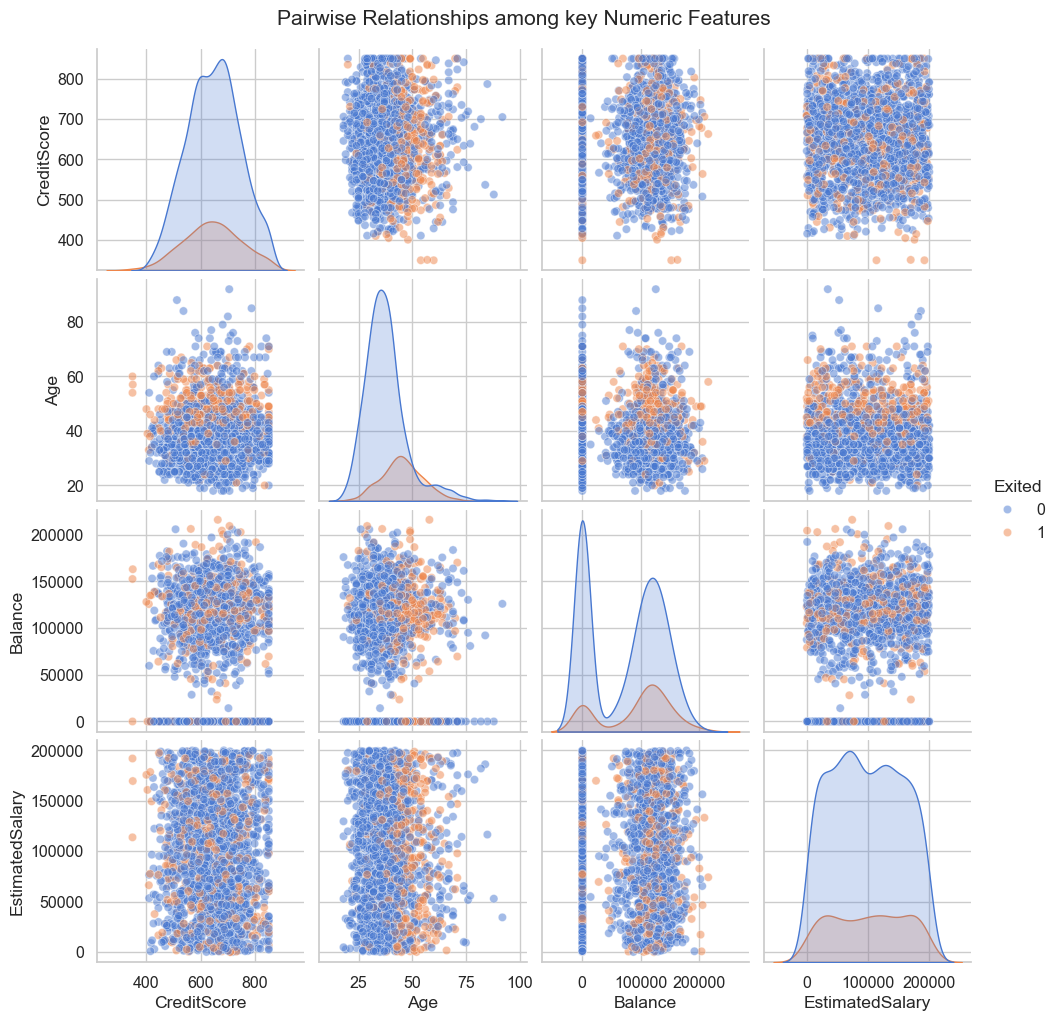

In [14]:
# --- Pairplot (sampled for speed)
sns.pairplot(df.sample(frac=0.2, random_state=42),
             vars=['CreditScore', 'Age', 'Balance', 'EstimatedSalary'], 
            hue='Exited', diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pairwise Relationships among key Numeric Features', y=1.02)
plt.show()

### 1. No strong linear relationships


Scatter plots (off-diagonal) look like random clouds & No clear upward/downward trend


Insight:
* Variables are not strongly correlated


### 2. Age stands out again (important)


In plots involving Age, orange points (churned) are more spread toward higher values


Insight:
* Older customers → higher churn


### 3. Balance distribution pattern confirmed


* Vertical cluster at Balance = 0
* Another cluster at high balances (~100k+)
* More orange points in higher balance region


Insight:
* High balance customers churn more


### 4. Salary is useless (again confirmed)


Completely random scatter everywhere


### The pairplot shows that there are **no strong linear relationships between the numeric variables**, indicating that **churn is likely driven by more complex interactions rather than simple correlations**. However, **age** consistently shows a pattern where older customers have higher churn probability. Additionally, balance shows a distinct clustering, with higher balance customers exhibiting more churn behavior. Estimated salary appears to have no significant relationship with churn.

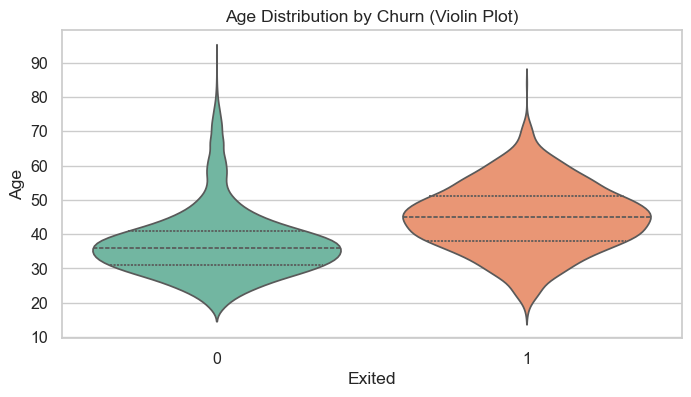

In [15]:
# --- Violin plot for Age
plt.figure(figsize=(8,4))
sns.violinplot(data=df, x='Exited', y='Age', inner='quart', palette='Set2')
plt.title('Age Distribution by Churn (Violin Plot)')
plt.show()

### Key Insights


Churned customers are older
* Distribution is clearly shifted to higher ages (≈40–55)


Median age is higher for churned users
* ~45 vs ~35 = ~10-year gap (strong signal)


Higher density in older age groups
* Indicates increased churn risk with age


Wider spread for churned group
* Older customers show more variability → less stable


Some overlap exists
* Age alone is not sufficient → needs combination with other features

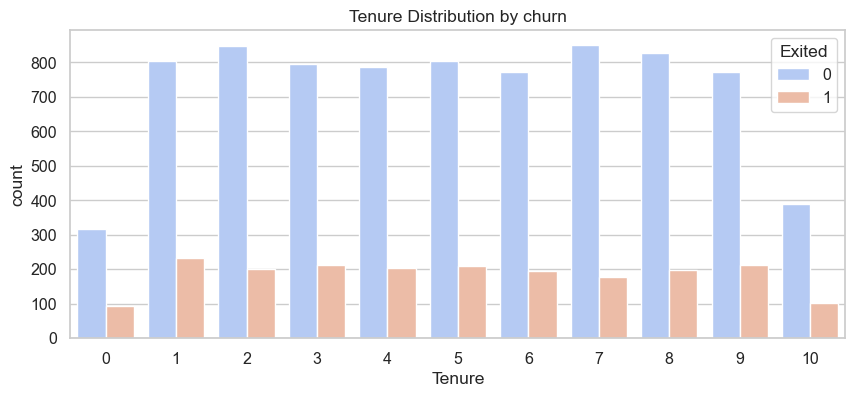

In [16]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='Tenure', hue='Exited', palette='coolwarm')
plt.title('Tenure Distribution by churn')
plt.show()

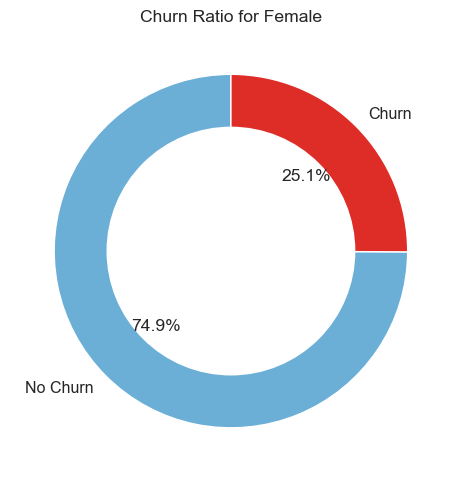

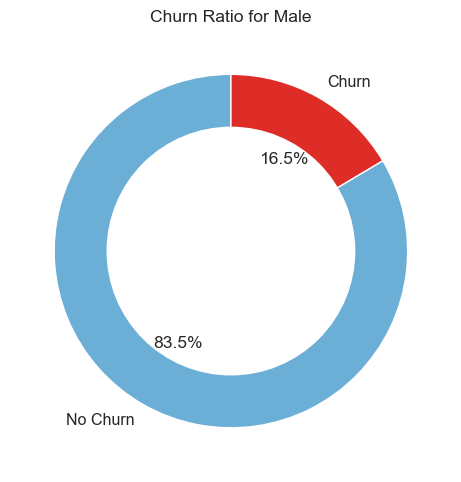

In [17]:
# --- Gender vs Churn Donut Chart
gender_counts = df.groupby('Gender')['Exited'].value_counts(normalize=True).unstack().fillna(0)
for gender in gender_counts.index:
    plt.figure(figsize=(5,5))
    plt.pie(gender_counts.loc[gender], labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', startangle=90, colors=['#6baed6', '#de2d26'])
    center = plt.Circle((0,0),0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(center)
    plt.title(f'Churn Ratio for {gender}')
    plt.tight_layout()
    plt.show()

### 1. Tenure vs Churn (Bar Chart)
Churn is fairly uniform across tenure
* No strong increasing/decreasing trend


Both new (0–1 yrs) and old (8–10 yrs) customers churn
* Loyalty duration doesn’t guarantee retention
* Slight variation exists, but no clear pattern

### 2. Churn by Gender (Donut Charts)
Females churn more than males
* Female churn ≈ 25.1%
* Male churn ≈ 16.5%


Non-churn is higher for both, but:
* Gap is significant between genders


### Tenure showed **no** strong relationship with churn, indicating that even long-term customers are at risk. However, gender revealed a clear pattern, with **female**  customers exhibiting significantly **higher churn rates**, suggesting the need for targeted retention strategies.”

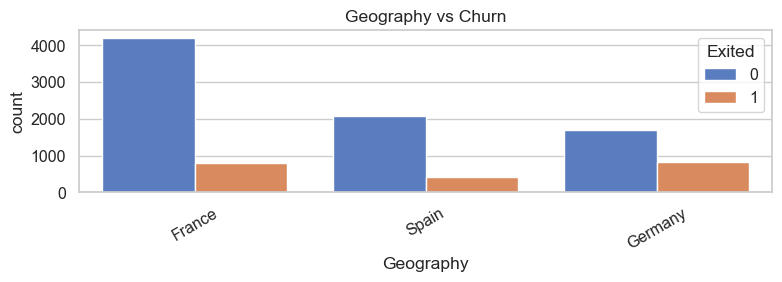

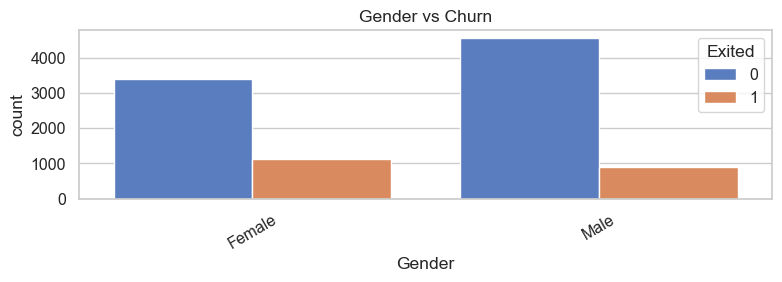

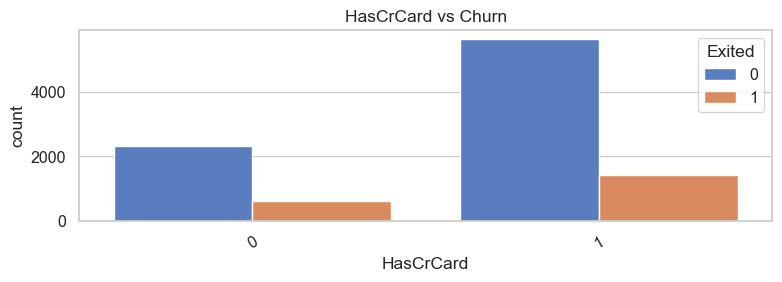

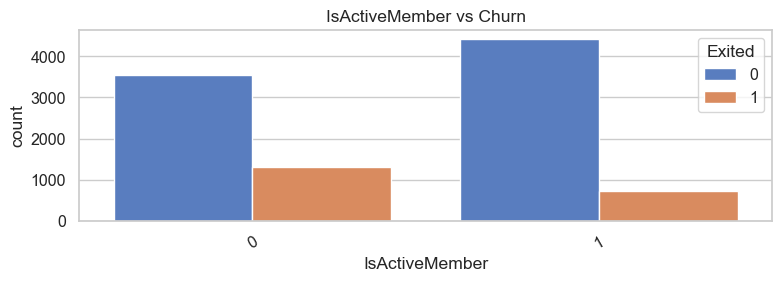

In [22]:
# --- Categorical features
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']
for c in cat_cols:
    plt.figure(figsize=(8,3))
    sns.countplot(data=df, x=c, hue='Exited')
    plt.title(f'{c} vs Churn')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### 1. Geography vs Churn (Bar Chart)
* Germany shows the highest risk of churn despite having a smaller total customer base than France.
* While France has the most customers, its churn count is comparable to Germany’s.
* Germany's churn rate is visually much higher (nearly 50% of its local base) compared to France or Spain.
* Spain and France show similar patterns.
* France has the highest retention in absolute numbers.
* Spain has the lowest overall count of both retained and churned customers.


### 2. Gender vs Churn (Bar Chart)
* Female customers exhibit a higher churn rate than male customers.
* indicates a proportionally higher churn among females.


### 3. HasCrCard vs Churn (Bar Chart)
* The vast majority of customers own a credit card (represented by '1').
* Churn exists in both categories, but the absolute number of churned customers is much higher among credit card holders.
* However, the ratio of churn to retention appears relatively consistent across both groups, suggesting credit card ownership isn't a primary driver of churn.


### 4. IsActiveMember vs Churn (Bar Chart)
* Inactive members (0) are significantly more likely to churn than active members (1).
* The churn bar (orange) for inactive members is much higher than for active members.
* Conversely, active members show a very high retention rate (the tallest blue bar in this chart).

### **Geography and Activity Status** show the **strongest** relationships with churn. Specifically, customers in **Germany and Inactive Members** are at the highest risk. While gender also plays a role, with females churning at a higher rate, having a credit card does not seem to significantly alter the likelihood of a customer leaving.

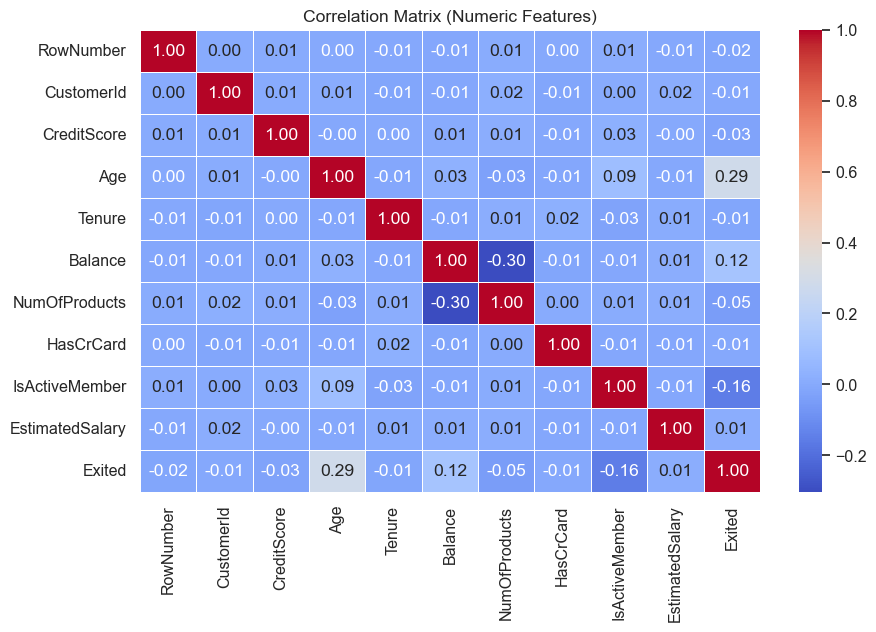

In [24]:
# --- Heatmap visualization
num_df = df.select_dtypes(include=['int64', 'float64'])
corr = num_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix (Numeric Features)')
plt.show()

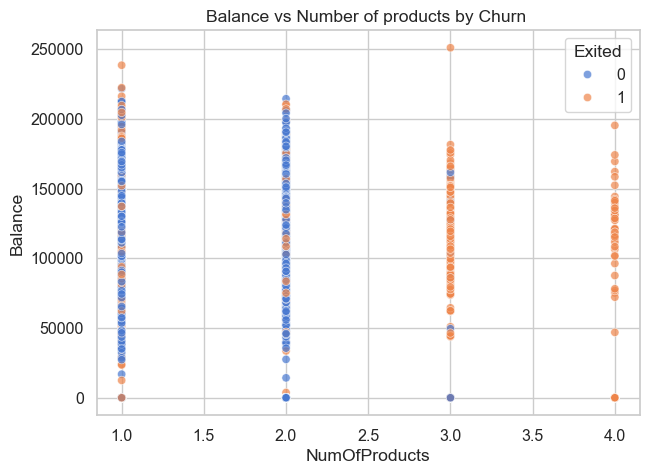

In [27]:
# --- Balance vs Products scatter
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='NumOfProducts', y='Balance', hue='Exited', alpha=0.7)
plt.title('Balance vs Number of products by Churn ')
plt.show()

In [28]:
print(df.columns)

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


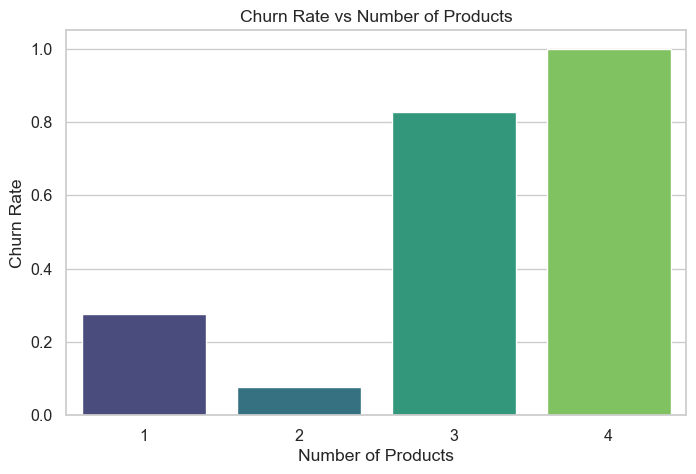

In [30]:
# --- Aggregate churn rate per number of products
churn_rate = df.groupby('NumOfProducts')['Exited'].mean().reset_index()

# Plot churn rate
plt.figure(figsize=(8,5))
sns.barplot(data=churn_rate, x='NumOfProducts', y='Exited', palette='viridis')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.title('Churn Rate vs Number of Products')
plt.show()

### 1. Correlation Matrix (Heatmap):
Age and Balance show the strongest positive correlations with churn (Exited).
* Age (0.29): As age increases, the likelihood of churning also tends to increase.
* Balance (0.12): Higher account balances are slightly correlated with a higher chance of exiting.


IsActiveMember has a negative correlation ($-0.16$) with churn.
* This confirms that being an active member significantly reduces the likelihood of leaving.


Most other features (RowNumber, CustomerId, CreditScore, Tenure, EstimatedSalary) have near-zero correlation with churn.


### 2. Balance vs Number of Products by Churn (Scatter Plot)
* Customers with 3 or 4 products are almost entirely orange (Exited), regardless of their balance.
* For those with 1 or 2 products, the dots are a mix of blue (stayed) and orange (left).
* There is a noticeable cluster of customers with 0 balance across 1 and 2 products.
* Having a balance of $0$ doesn't automatically mean a customer will churn.


### 3. Churn Rate vs Number of Products (Bar Chart)
* The "Sweet Spot" for retention is 2 products.Customers with 2 products have the lowest churn rate.
* Having only 1 product results in a moderate churn rate.
* Extreme product counts (3 and 4) are high-risk indicators.
    * 3 Products: Churn rate jumps to over 80%.
    * 4 Products: Churn rate is nearly 100%. 


This suggests that customers who end up with 4 products are almost certainly leaving or are being off-boarded.Age is the most significant numeric predictor of churn, with older customers leaving at higher rates. More critically, the Number of Products is a non-linear driver: while having 2 products is ideal for retention, increasing that number to 3 or 4 correlates with a nearly guaranteed exit, possibly indicating that these customers are consolidating accounts before leaving.

## Step 5. Feature Engineering
Create meaningful features: e.g balance per product, age group, salary bracket and handle missing values

In [34]:
# Feature engineering examples
df_fe = df.copy()

# Balance per product
df_fe['balance_per_product'] = df_fe['Balance'] / (df_fe['NumOfProducts'].replace(0, np.nan))
df_fe['balance_per_product'].fillna(0, inplace=True)

# Salary to balance ratio
df_fe['salary_balance_ratio'] = df_fe['EstimatedSalary'] / (df_fe['Balance'].replace(0, np.nan))
df_fe['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_fe['salary_balance_ratio'].fillna(df_fe['salary_balance_ratio'].median(), inplace=True)

# Age group
bins = [0,25,35,45,55,65,100]
labels = ['<25','25-34','35-44','45-54','55-64','65+']
df_fe['age_group'] = pd.cut(df_fe['Age'], bins=bins, labels=labels)

# Tenure bucket
df_fe['tenure_bucket'] = pd.cut(df_fe['Tenure'], bins=[-1,0,2,5,10,100], labels=['0','1-2','3-5','6-10','10+'])

# Flag high balance
df_fe['high_balance'] = (df_fe['Balance'] > df_fe['Balance'].quantile(0.75)).astype(int)

# Quick checks
df_fe[['balance_per_product','salary_balance_ratio','Age','age_group','Tenure','tenure_bucket','high_balance']].head()

,balance_per_product,salary_balance_ratio,Age,age_group,Tenure,tenure_bucket,high_balance
0,0.000000,0.839258,42,35-44,2,1-2,0
1,83807.860000,1.342864,41,35-44,1,1-2,0
2,53220.266667,0.713585,42,35-44,8,6-10,1
3,0.000000,0.839258,39,35-44,1,1-2,0
4,125510.820000,0.630098,43,35-44,2,1-2,0


## Step 6. Preprocessing - encoding & scaling
We'll build a preprocessing pipeline that encodes categorical features and scales numerical ones.

In [35]:
print(df.columns)

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [36]:
# Define features and target
target = 'Exited'
drop_cols = ['CustomerId']
features = [c for c in df_fe.columns if c not in [target] + drop_cols]

numeric_features = ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary',
                    'balance_per_product','salary_balance_ratio']
categorical_features = ['Geography','Gender','HasCrCard','IsActiveMember','age_group','tenure_bucket','high_balance']

df_fe[categorical_features] = df_fe[categorical_features].astype('object')

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'balance_per_product', 'salary_balance_ratio']
Categorical features: ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'age_group', 'tenure_bucket', 'high_balance']


## Step 7. Train Test split

In [37]:
X = df_fe[features]
y = df_fe[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Train churn proportion:', y_train.mean(), 'Test churn proportion:', y_test.mean())

Train shape: (8000, 17) Test shape: (2000, 17)
Train churn proportion: 0.20375 Test churn proportion: 0.2035


## Step 8. Train Multiple models with a pipeline and compare using cross-validation